# IY025: SVM on Pairwise-Labelled Variation Data (IY011 vs IY014)

How well can an SVM distinguish **same-parameter-set** from **different-parameter-set** trajectory pairs, and how does that depend on which statistic varies and by how much?

## Labelling approach

Labels come from the **contrastive data preparation in IY011** (`IY011_contrastive_learning_data_prep.ipynb`). Trajectories are assembled into pairs:
- **Positive (label 1):** both trajectories drawn from the *same* parameter set
- **Negative (label 0):** trajectories drawn from *different* parameter sets

No analyst-assigned threshold is involved — the label is structural (pair identity). The pre-built `.pt` loaders (`IY011_static_train.pt` / `_test.pt`) encode this pairwise structure and are loaded directly here.

## Variation conditions

Each dataset holds all parameters fixed and varies only one statistic, or all three together (baseline):
- **baseline** — μ, CV, and t_ac all vary (Sobol sampling)
- **mu** — only μ varies; CV and t_ac held fixed
- **cv** — only CV varies; μ and t_ac held fixed
- **t_ac** — only t_ac varies; μ and CV held fixed

## Variation magnitudes

- **IY011 (2-fold):** the varied statistic differs by ~2× between the two classes
- **IY014 (10-fold):** the varied statistic differs by ~10× between the two classes

Comparing the two magnitudes shows how SVM performance scales with effect size for each statistic.


## Purpose

Time series from stochastic gene-expression simulations can be characterised by three summary statistics: mean expression level (μ), coefficient of variation (CV), and autocorrelation time (t_ac). In the variation experiments, two classes are generated by holding all other parameters fixed and varying only one statistic (or all three together in the baseline). The question is:

> **Can an SVM trained on raw (flattened, normalised) time series distinguish the two classes — and how does that ability depend on (a) which statistic is varied and (b) the magnitude of the variation?**

We test two magnitudes:
- **IY011 (2-fold)**: the varied statistic differs by ~2× between classes
- **IY014 (10-fold)**: the varied statistic differs by ~10× between classes

A higher accuracy indicates that the chosen statistic leaves a detectable imprint on the raw trajectory even after instance normalisation. Comparing 2-fold vs. 10-fold shows how SVM performance scales with effect size across each statistic.

A **permutation control** is included in each case: the time-axis of every trajectory is independently shuffled before feeding to the SVM. This destroys temporal autocorrelation while leaving the marginal distribution of each trajectory intact (mean and variance are unchanged). Permuted accuracy estimates how much of the SVM's signal comes from *temporal structure* vs. *static distributional features* (e.g. variance differences visible even in a histogram).

In [1]:
import sys
sys.path.insert(0, '../../src')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

from dataloaders import load_loader_from_disk
from classifiers.svm_classifier import svm_classifier

%load_ext autoreload
%autoreload 2

## Configuration

In [2]:
IY011_ROOT = Path('../EXP-25-IY011')
IY014_ROOT = Path('../EXP-26-IY014')

# IY011 (2-fold variation)
IY011_EXPERIMENTS = [
    {
        'name': 'baseline',
        'train': IY011_ROOT / 'data' / 'IY011_static_train.pt',
        'test':  IY011_ROOT / 'data' / 'IY011_static_test.pt',
        'color': 'black',
    },
    {
        'name': 'mu',
        'train': IY011_ROOT / 'data_mu_variation' / 'IY011_static_train.pt',
        'test':  IY011_ROOT / 'data_mu_variation' / 'IY011_static_test.pt',
        'color': 'blue',
    },
    {
        'name': 'cv',
        'train': IY011_ROOT / 'data_cv_variation' / 'IY011_static_train.pt',
        'test':  IY011_ROOT / 'data_cv_variation' / 'IY011_static_test.pt',
        'color': 'green',
    },
    {
        'name': 't_ac',
        'train': IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_train.pt',
        'test':  IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_test.pt',
        'color': 'red',
    },
]

# IY014 (10-fold variation)
# Note: mu variation data lives in IY011's folder (same dataset, different fold)
IY014_EXPERIMENTS = [
    {
        'name': 'baseline',
        'train': IY014_ROOT / 'data' / 'IY014_static_train.pt',
        'test':  IY014_ROOT / 'data' / 'IY014_static_test.pt',
        'color': 'black',
    },
    {
        'name': 'mu',
        'train': IY011_ROOT / 'data_mu_variation' / 'IY014_static_train.pt',
        'test':  IY011_ROOT / 'data_mu_variation' / 'IY014_static_test.pt',
        'color': 'blue',
    },
    {
        'name': 'cv',
        'train': IY014_ROOT / 'data_cv_variation' / 'IY014_static_train.pt',
        'test':  IY014_ROOT / 'data_cv_variation' / 'IY014_static_test.pt',
        'color': 'green',
    },
    {
        'name': 't_ac',
        'train': IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_train.pt',
        'test':  IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_test.pt',
        'color': 'red',
    },
]

## Helper Functions

In [3]:
import seaborn as sns

# ── Plotting conventions ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "sans-serif",
    "axes.labelsize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titlesize":  14,
})

def _colours(n):
    return sns.color_palette("colorblind", n_colors=n)


# ── Data helpers ──────────────────────────────────────────────────────────────
def extract_data_for_svm(loader):
    """Flatten (B, T, C) loader batches into (N, T*C) arrays for SVM input."""
    X_list, y_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_list.append(X_batch.cpu().numpy().reshape(X_batch.shape[0], -1))
            y_list.append(y_batch.cpu().numpy().ravel())
    return np.vstack(X_list), np.concatenate(y_list)


def run_svm_for_experiment(exp):
    """Load data, scale, and evaluate SVM for a single experiment config."""
    train_loader = load_loader_from_disk(exp['train'], batch_size=256)
    test_loader  = load_loader_from_disk(exp['test'],  batch_size=256)

    X_train, y_train = extract_data_for_svm(train_loader)
    X_test,  y_test  = extract_data_for_svm(test_loader)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    acc = svm_classifier(X_train, X_test, y_train, y_test)
    print(f"  [{exp['name']}] SVM accuracy: {acc:.4f}")
    return acc


# ── Plot helper ───────────────────────────────────────────────────────────────
def plot_svm_results(experiments, accuracies, title, ax):
    """Bar chart of SVM accuracy by experiment condition."""
    labels  = [e['name'] for e in experiments]
    colours = _colours(len(labels))
    x = np.arange(len(labels))

    bars = ax.bar(x, accuracies, color=colours, width=0.5,
                  edgecolor='black', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2g', padding=3)
    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1,
               label='Chance (0.50)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Varied statistic')
    ax.set_ylabel('Test accuracy (fraction correct)')
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)


## Run SVM on IY011 (2-fold variation)

In [4]:
print('=== IY011: 2-fold variation ===')
iy011_accs = []
for exp in IY011_EXPERIMENTS:
    print(f'\nExperiment: {exp["name"]}')
    acc = run_svm_for_experiment(exp)
    iy011_accs.append(acc)

print('\nSummary (IY011):')
for exp, acc in zip(IY011_EXPERIMENTS, iy011_accs):
    print(f'  {exp["name"]:12s}: {acc:.4f}')

=== IY011: 2-fold variation ===

Experiment: baseline
📂 Loading static data from ../EXP-25-IY011/data/IY011_static_train.pt...
📂 Loading static data from ../EXP-25-IY011/data/IY011_static_test.pt...
=== SVM (RBF Kernel) Classification Accuracy: 0.70 ===
  [baseline] SVM accuracy: 0.7050

Experiment: mu
📂 Loading static data from ../EXP-25-IY011/data_mu_variation/IY011_static_train.pt...
📂 Loading static data from ../EXP-25-IY011/data_mu_variation/IY011_static_test.pt...
=== SVM (RBF Kernel) Classification Accuracy: 0.93 ===
  [mu] SVM accuracy: 0.9333

Experiment: cv
📂 Loading static data from ../EXP-25-IY011/data_cv_variation/IY011_static_train.pt...
📂 Loading static data from ../EXP-25-IY011/data_cv_variation/IY011_static_test.pt...
=== SVM (RBF Kernel) Classification Accuracy: 0.63 ===
  [cv] SVM accuracy: 0.6317

Experiment: t_ac
📂 Loading static data from ../EXP-25-IY011/data_t_ac_variation/IY011_static_train.pt...
📂 Loading static data from ../EXP-25-IY011/data_t_ac_variation/IY0

## Run SVM on IY014 (10-fold variation)

In [5]:
print('=== IY014: 10-fold variation ===')
iy014_accs = []
for exp in IY014_EXPERIMENTS:
    print(f'\nExperiment: {exp["name"]}')
    acc = run_svm_for_experiment(exp)
    iy014_accs.append(acc)

print('\nSummary (IY014):')
for exp, acc in zip(IY014_EXPERIMENTS, iy014_accs):
    print(f'  {exp["name"]:12s}: {acc:.4f}')

=== IY014: 10-fold variation ===

Experiment: baseline
📂 Loading static data from ../EXP-26-IY014/data/IY014_static_train.pt...
📂 Loading static data from ../EXP-26-IY014/data/IY014_static_test.pt...


=== SVM (RBF Kernel) Classification Accuracy: 0.79 ===
  [baseline] SVM accuracy: 0.7883

Experiment: mu
📂 Loading static data from ../EXP-25-IY011/data_mu_variation/IY014_static_train.pt...
📂 Loading static data from ../EXP-25-IY011/data_mu_variation/IY014_static_test.pt...
=== SVM (RBF Kernel) Classification Accuracy: 1.00 ===
  [mu] SVM accuracy: 0.9983

Experiment: cv
📂 Loading static data from ../EXP-26-IY014/data_cv_variation/IY014_static_train.pt...
📂 Loading static data from ../EXP-26-IY014/data_cv_variation/IY014_static_test.pt...
=== SVM (RBF Kernel) Classification Accuracy: 0.96 ===
  [cv] SVM accuracy: 0.9583

Experiment: t_ac
📂 Loading static data from ../EXP-26-IY014/data_t_ac_variation/IY014_static_train.pt...
📂 Loading static data from ../EXP-26-IY014/data_t_ac_variation/IY014_static_test.pt...
=== SVM (RBF Kernel) Classification Accuracy: 0.81 ===
  [t_ac] SVM accuracy: 0.8133

Summary (IY014):
  baseline    : 0.7883
  mu          : 0.9983
  cv          : 0.9583
  t_ac

## Plots

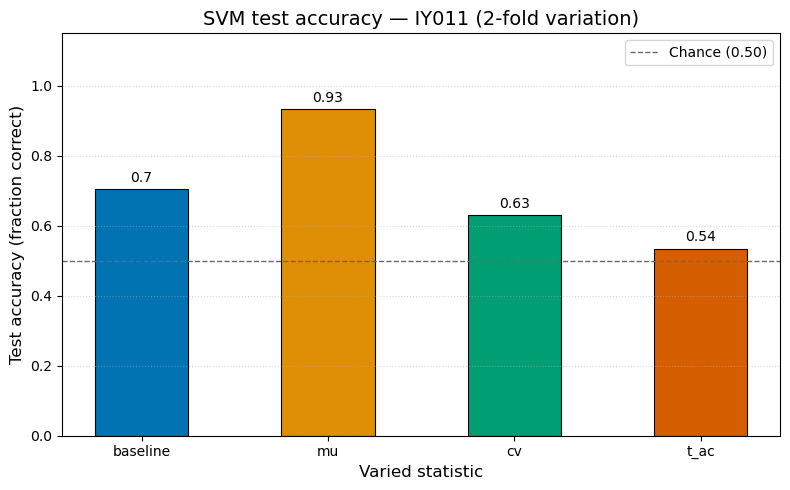

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_svm_results(
    IY011_EXPERIMENTS, iy011_accs,
    'SVM test accuracy — IY011 (2-fold variation)', ax
)
plt.tight_layout()
plt.savefig('IY025_svm_pairwise_variation_2fold.png', dpi=150, bbox_inches='tight')
plt.show()


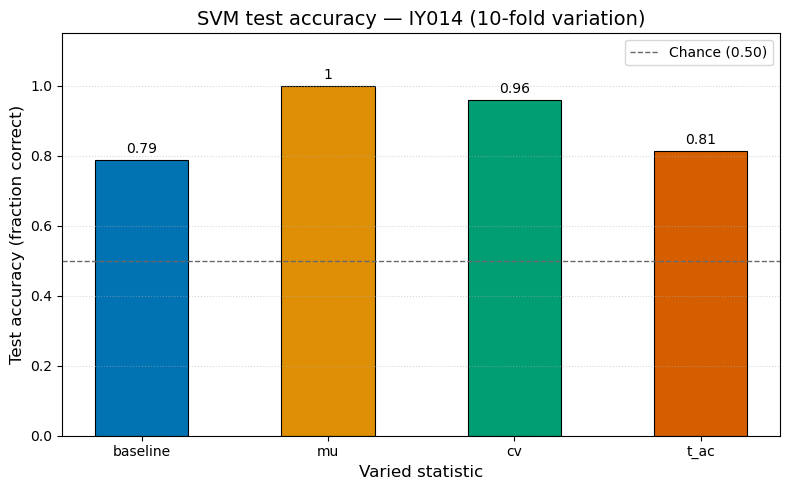

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_svm_results(
    IY014_EXPERIMENTS, iy014_accs,
    'SVM test accuracy — IY014 (10-fold variation)', ax
)
plt.tight_layout()
plt.savefig('IY025_svm_pairwise_variation_10fold.png', dpi=150, bbox_inches='tight')
plt.show()


## Side-by-side comparison

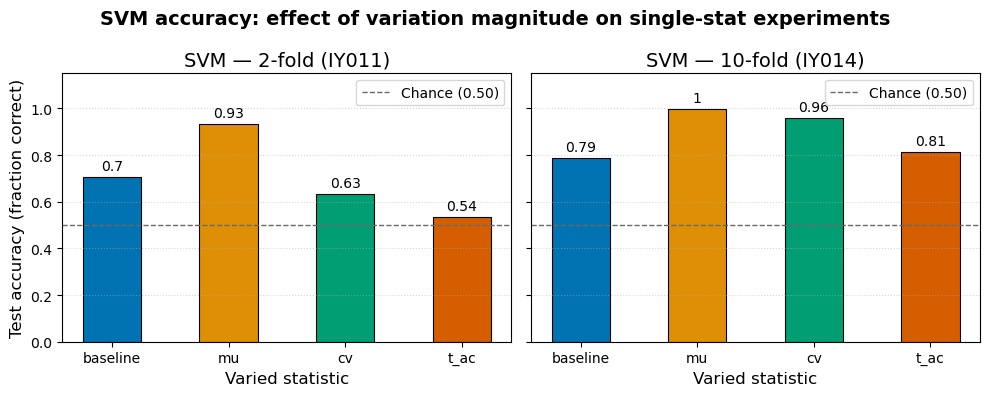

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plot_svm_results(IY011_EXPERIMENTS, iy011_accs, 'SVM — 2-fold (IY011)', axes[0])
plot_svm_results(IY014_EXPERIMENTS, iy014_accs, 'SVM — 10-fold (IY014)', axes[1])
axes[1].set_ylabel('')
fig.suptitle(
    'SVM accuracy: effect of variation magnitude on single-stat experiments',
    fontsize=14, weight='bold'
)
plt.tight_layout()
plt.savefig('IY025_svm_pairwise_variation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
